In [1]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re

from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler 
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    ##  K-means 임포트
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

plt.rc('font',family='D2CodingLigature Nerd Font')
# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시

# 타이타닉 생존자 분석

1. 데이터셋 출처 (데이터 가져오기)
* 본 데이터셋은 Seaborn 시각화 라이브러리에 내장된 데이터를 사용하며, 원본은 Kaggle의 타이타닉 생존자 예측 경진대회 데이터입니다.
* 목표는 승객들의 다양한 정보를 바탕으로 생존 여부를 결정짓는 주요 요인을 분석하는 것입니다.
* 출처: https://www.kaggle.com/c/titanic/data
* 파일명: titanic (Seaborn 내장 데이터프레임)

2. 데이터 구성 (Feature Description)
* 타이타닉 승객의 특성 14개와 생존 여부(Target)로 이루어져 있습니다.
* survived: 생존 여부 (0: 사망, 1: 생존) - 종속변수
* pclass: 객실 등급 (1: 1등석, 2: 2등석, 3: 3등석)
* sex: 성별 (male, female)
* age: 나이 (연령대 분석 시 핵심 변수)
* sibsp: 함께 탑승한 형제 자매 또는 배우자의 수
* parch: 함께 탑승한 부모 또는 자녀의 수
* fare: 승객 요금 (경제적 수준의 척도)
* embarked: 탑승 항구 (C, Q, S)
* who: 남자, 여자, 아이 구분
* adult_male: 성인 남성 여부 (True, False)
* deck: 객실이 위치한 구역 (A~G)
* embark_town: 탑승 항구 이름
* alive: 생존 여부 (yes, no)
* alone: 혼자 탑승 여부 (True, False)

In [2]:
# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 시각화설정 맑은고딕,숫자 앞 마이너스(-) 기호 깨지지 않게,하얀배경 회색줄
# plt.rc('font', family='Malgun Gothic') 
# plt.rc('axes', unicode_minus=False)
sns.set(style="whitegrid")
print("타이타닉 분석용 라이브러리 import 완료")

타이타닉 분석용 라이브러리 import 완료


## 1. 데이터 수집

In [3]:
titanic = sns.load_dataset('titanic')
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [4]:
print(f"전체 데이터 수: {len(titanic)}")
print(f"컬럼명 : {titanic.columns.tolist()}\n")
titanic.info()

전체 데이터 수: 891
컬럼명 : ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool  

## 2. 데이터 전처리

In [5]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
# age의 결측치는 age의 중앙값으로 채운다
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
titanic['embarked'].value_counts(dropna = False)

embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

In [8]:
# embarked의 결측치는 2건이므로 빈도수가 높은 'S'로 지정
titanic['embarked'] = titanic['embarked'].fillna('S')
titanic['embarked'].value_counts(dropna = False)

embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [9]:
titanic['embark_town'].value_counts(dropna=False)

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
NaN              2
Name: count, dtype: int64

In [10]:
titanic['embark_town'] = titanic['embark_town'].fillna('Southampton')
titanic['embark_town'].value_counts(dropna=False)

embark_town
Southampton    646
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [11]:
titanic['deck'].value_counts(dropna=False)

deck
NaN    688
C       59
B       47
D       33
E       32
A       15
F       13
G        4
Name: count, dtype: int64

In [12]:
titanic['deck'] = titanic['deck'].fillna('C')
titanic['deck'].value_counts(dropna=False)

deck
C    747
B     47
D     33
E     32
A     15
F     13
G      4
Name: count, dtype: int64

In [13]:
titanic.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

## 3. 데이터 분석

In [14]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         891 non-null    category
 12  embark_town  891 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [15]:
titanic.survived.value_counts() # 사망 0, 생존 1

survived
0    549
1    342
Name: count, dtype: int64

In [27]:
titanic.groupby('sex', as_index=False)['survived'].value_counts()

,sex,survived,count
0,female,1,233
1,female,0,81
2,male,0,468
3,male,1,109


In [ ]:
titanic.groupby('sex', as_index=False)['survived'].value_counts(normalize=True) # 비중으로 보기

,sex,survived,proportion
0,female,1,0.742038
1,female,0,0.257962
2,male,0,0.811092
3,male,1,0.188908


In [ ]:
titanic.groupby('sex')['survived'].value_counts(normalize=True).sort_index().reset_index()

,sex,survived,proportion
0,female,0,0.257962
1,female,1,0.742038
2,male,0,0.811092
3,male,1,0.188908


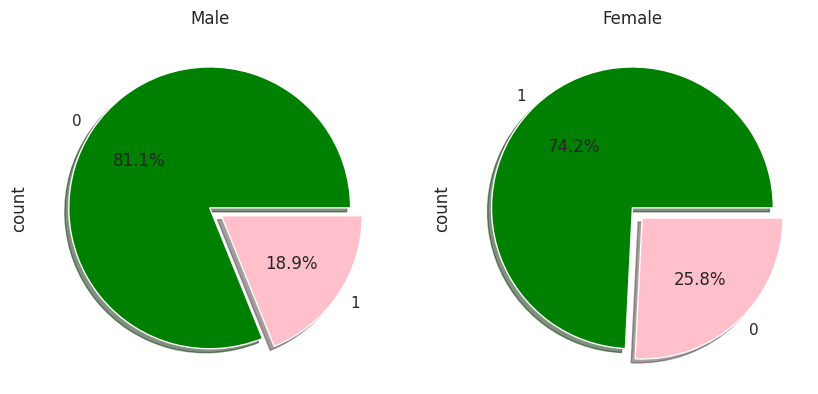

In [ ]:
# 문제가 있는 시각화

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
colors = ['green', 'pink'] 

# 남자
titanic['survived'][titanic['sex'] == 'male'].value_counts().plot.pie(
    explode=[0, 0.1], autopct='%1.1f%%', ax=ax[0], shadow=True, colors=colors)
ax[0].set_title('Male')

# 여자
titanic['survived'][titanic['sex'] == 'female'].value_counts().plot.pie(
    explode=[0, 0.1], autopct='%1.1f%%', ax=ax[1], shadow=True, colors=colors)
ax[1].set_title('Female')

plt.show()

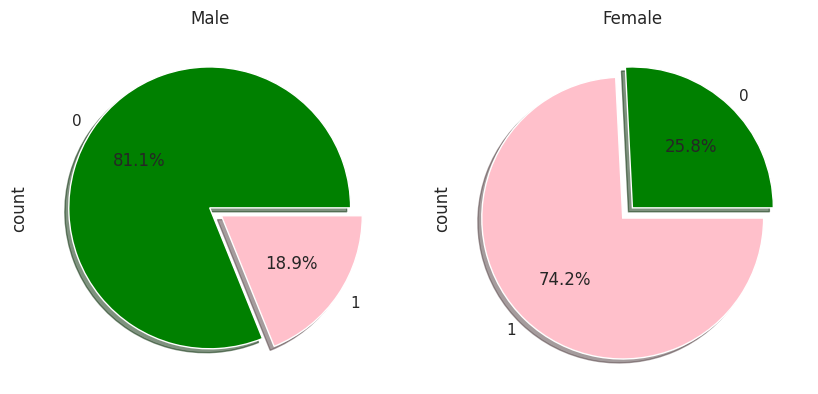

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
colors = ['green', 'pink'] 

# 남자
titanic['survived'][titanic['sex'] == 'male'].value_counts().sort_index().plot.pie(
    explode=[0, 0.1], autopct='%1.1f%%', ax=ax[0], shadow=True, colors=colors)
ax[0].set_title('Male')

# 여자
titanic['survived'][titanic['sex'] == 'female'].value_counts().sort_index().plot.pie(
    explode=[0, 0.1], autopct='%1.1f%%', ax=ax[1], shadow=True, colors=colors)
ax[1].set_title('Female')

plt.show()

In [28]:
# 등급별 생존확률 확인
titanic.groupby('pclass')['survived'].mean()

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

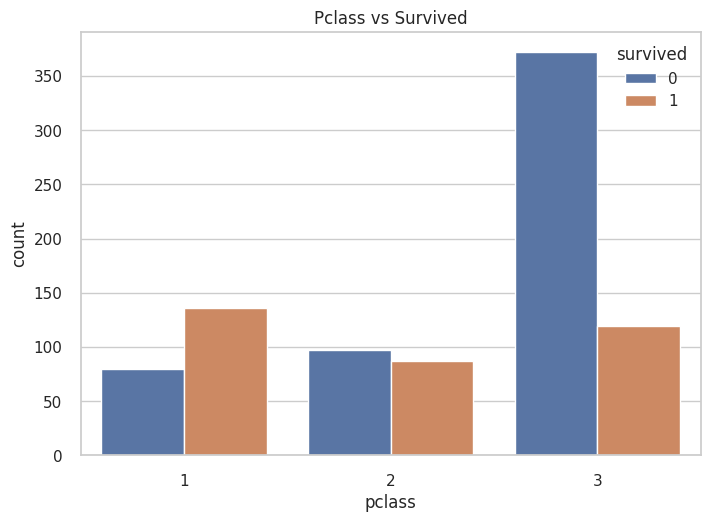

In [29]:
# 등급별 생존수를 시각화
sns.countplot(x='pclass', hue='survived', data=titanic)
plt.title('Pclass vs Survived')
plt.show()

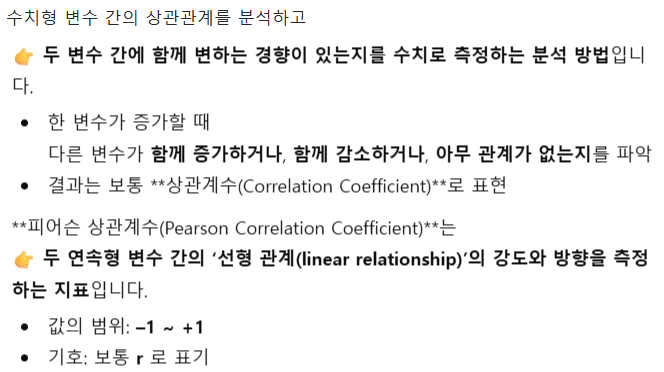

In [ ]:
# 상관분석을 위한 수치 데이터만 가져옴

titanic2 = titanic.select_dtypes(include=[int, float, bool])
titanic2.shape

(891, 8)

In [31]:
# 피어슨 상관계수 계산
titanic_corr = titanic2.corr(method='pearson')
titanic_corr

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,-0.557080,-0.203367
pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,0.094035,0.135207
age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,0.247704,0.171647
sibsp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,-0.253586,-0.584471
parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,-0.349943,-0.583398
fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,-0.182024,-0.271832
adult_male,-0.557080,0.094035,0.247704,-0.253586,-0.349943,-0.182024,1.000000,0.404744
alone,-0.203367,0.135207,0.171647,-0.584471,-0.583398,-0.271832,0.404744,1.000000


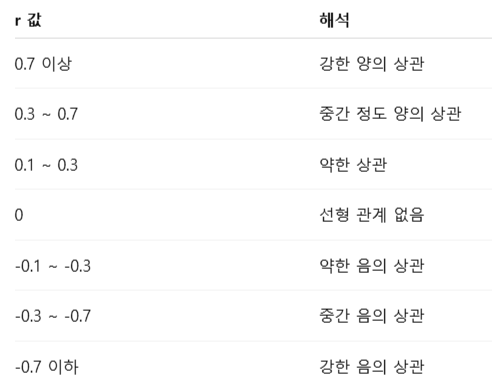

In [32]:
titanic['survived'].corr(titanic['adult_male'])

np.float64(-0.5570800422053257)

In [33]:
titanic['survived'].corr(titanic['fare'])

np.float64(0.2573065223849625)

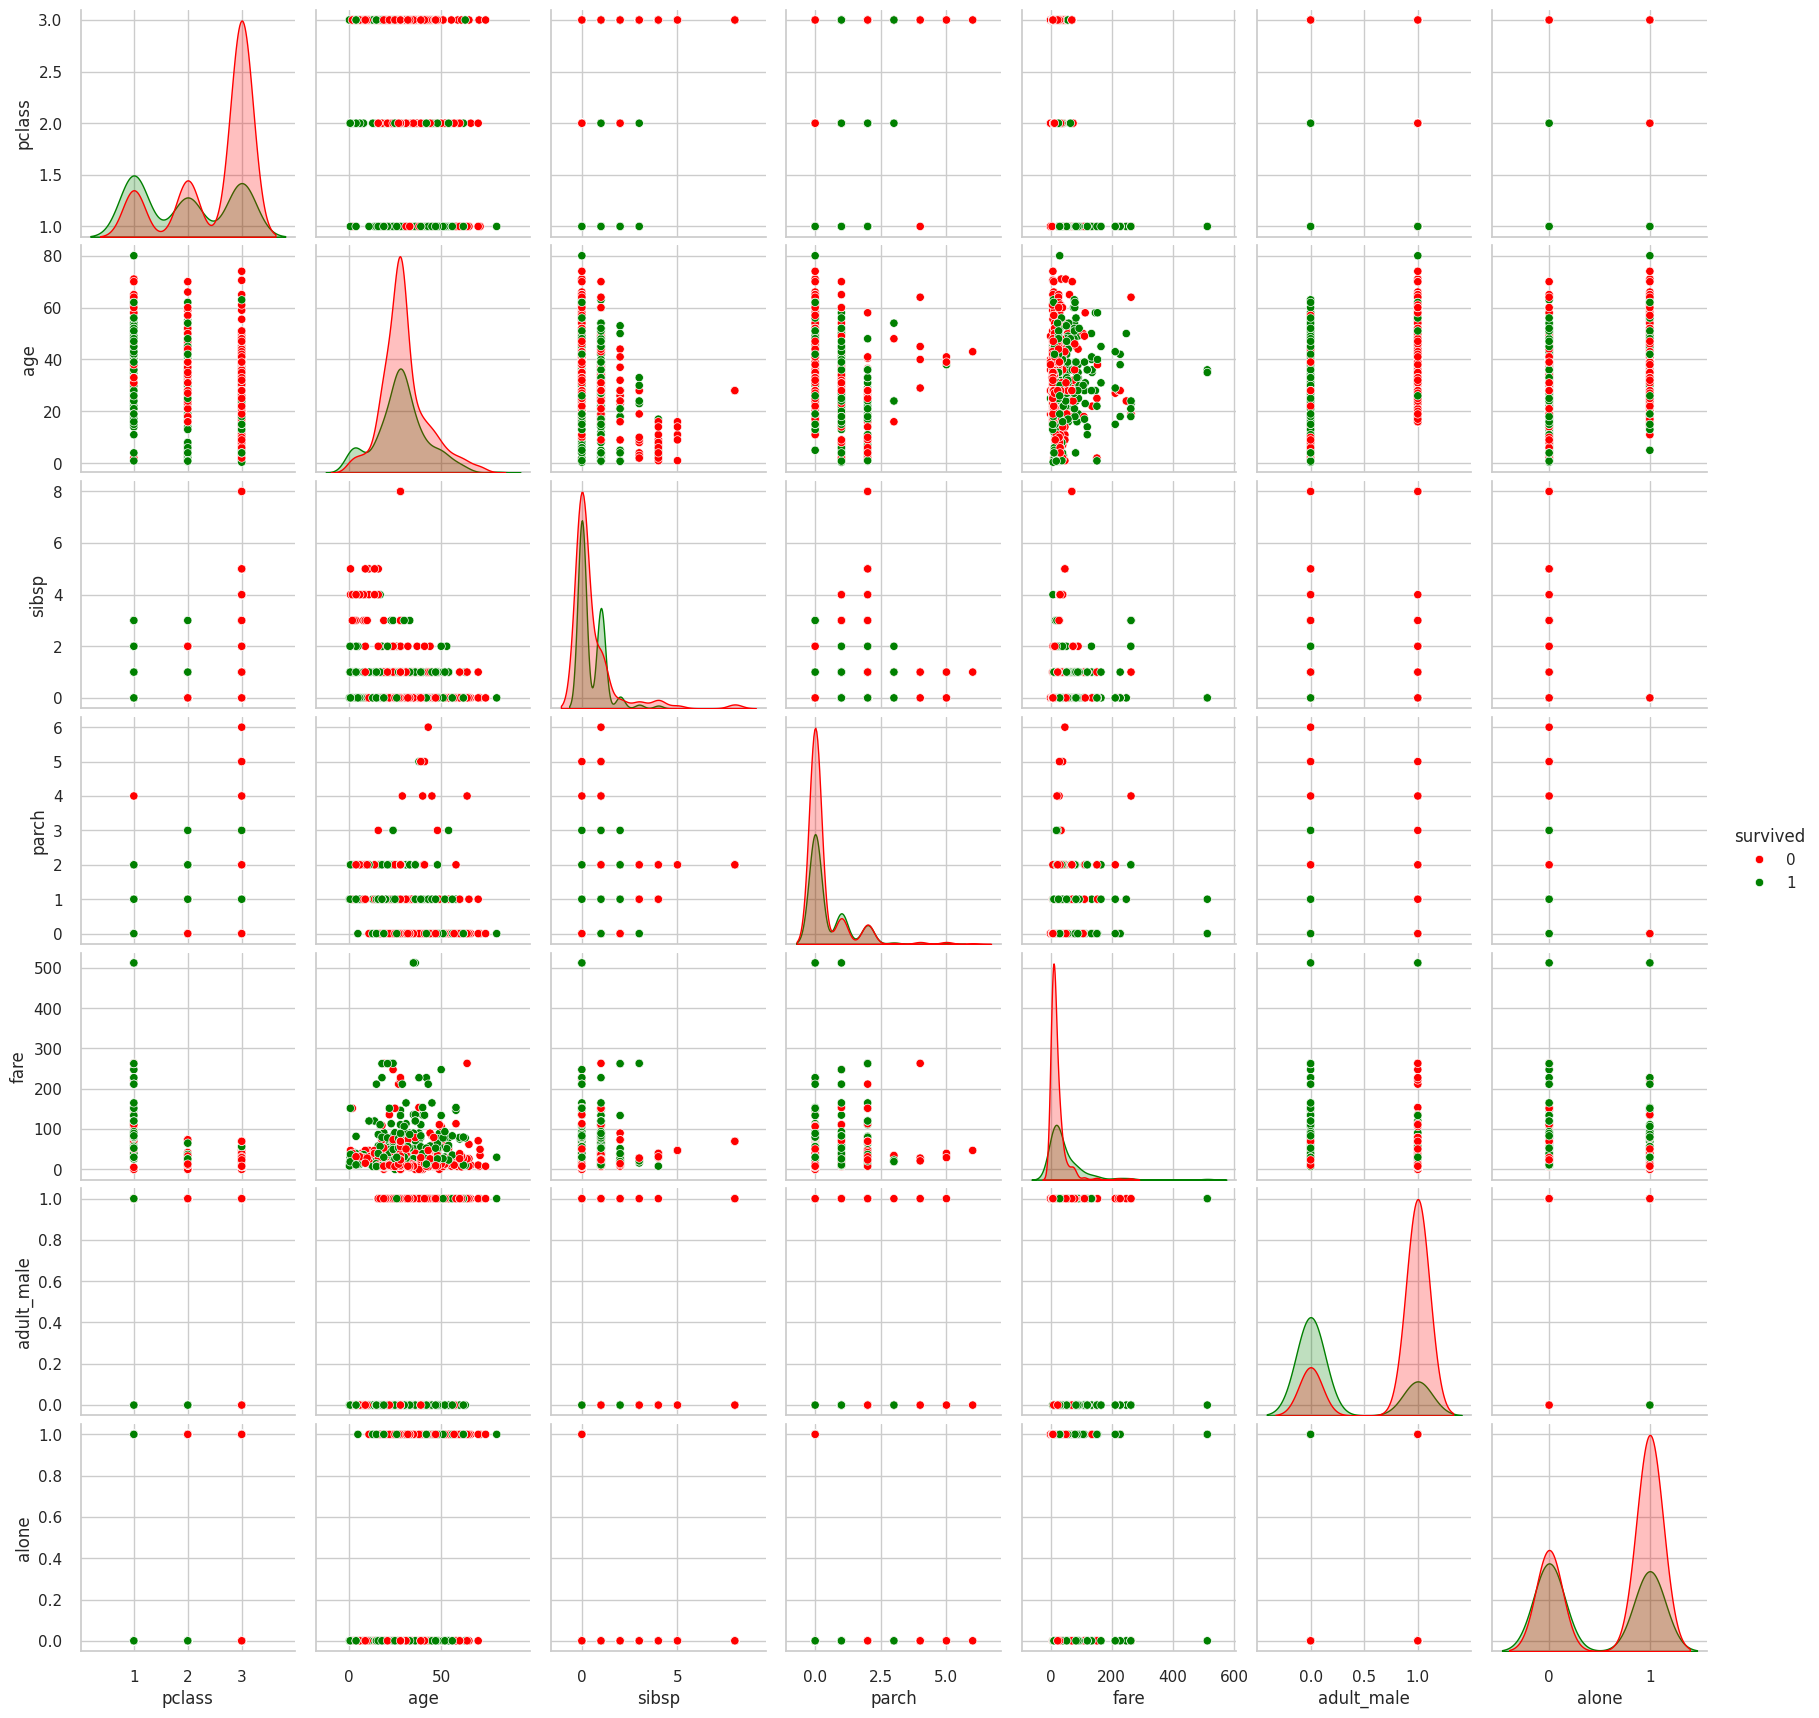

In [34]:
# 산점도로 상관분석 시각화
sns.pairplot(titanic, hue = 'survived', palette={0: 'red', 1: 'green'})
plt.show()

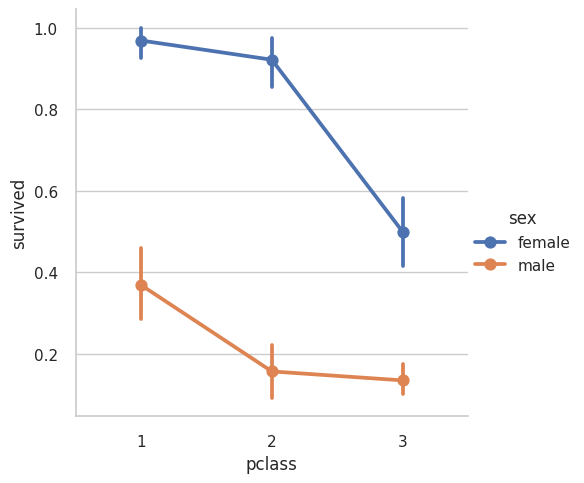

In [35]:
# 다변량 분석
# 객실등급, 성별, 생존여부
sns.catplot(x='pclass', y='survived', hue='sex', data=titanic, kind='point')
plt.show()

## 4. 히트맵으로 시각화

In [38]:
def category_age(x):
    if x<10:
        return 0
    elif x<20:
        return 1
    elif x<30:
        return 2
    elif x<40:
        return 3
    elif x<50:
        return 4
    elif x<60:
        return 5
    elif x<70:
        return 6
    else:
        return 7

titanic['age2'] = titanic['age'].apply(category_age)
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age2
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,C,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,3
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,C,Southampton,yes,True,2
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,3
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,C,Southampton,no,True,3


In [39]:
titanic['sex'] = titanic['sex'].map({'male':1, 'female':0})
titanic['family'] = titanic['sibsp'] + titanic['parch'] + 1

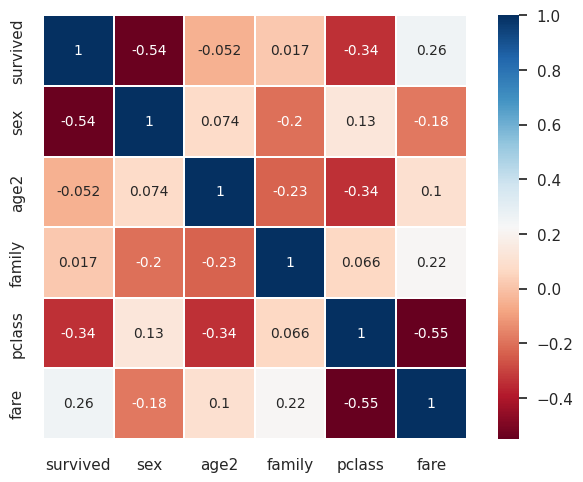

In [40]:
heatmap_data = titanic[['survived', 'sex', 'age2', 'family', 'pclass', 'fare']]
colormap = plt.cm.RdBu
sns.heatmap(heatmap_data.astype(float).corr(), linewidths = 0.1, vmax = 1.0, square = True, cmap = colormap, 
                                                    linecolor = 'white', annot = True, annot_kws = {"size": 10})

plt.show()

In [ ]:
# 불필요한 컬럼 제거
titanic.drop(columns=['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male'], inplace=True)
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone,age2,family
0,0,3,1,22.0,1,0,7.2500,S,False,2,2
1,1,1,0,38.0,1,0,71.2833,C,False,3,2
2,1,3,0,26.0,0,0,7.9250,S,True,2,1
3,1,1,0,35.0,1,0,53.1000,S,False,3,2
4,0,3,1,35.0,0,0,8.0500,S,True,3,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,S,True,2,1
887,1,1,0,19.0,0,0,30.0000,S,True,1,1
888,0,3,0,28.0,1,2,23.4500,S,False,2,4
889,1,1,1,26.0,0,0,30.0000,C,True,2,1


In [42]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    int64  
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    object 
 8   alone     891 non-null    bool   
 9   age2      891 non-null    int64  
 10  family    891 non-null    int64  
dtypes: bool(1), float64(2), int64(7), object(1)
memory usage: 70.6+ KB


In [ ]:
titanic = pd.get_dummies(titanic, columns=['sex', 'embarked'], drop_first=True) # sex_0, embarked_C 가 삭제되었다
titanic.head()

,survived,pclass,age,sibsp,parch,fare,alone,age2,family,sex_1,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,False,2,2,True,False,True
1,1,1,38.0,1,0,71.2833,False,3,2,False,False,False
2,1,3,26.0,0,0,7.9250,True,2,1,False,False,True
3,1,1,35.0,1,0,53.1000,False,3,2,False,False,True
4,0,3,35.0,0,0,8.0500,True,3,1,True,False,True


## 5. 의사결정나무

In [46]:
feature = ['pclass', 'sex_1', 'age2', 'fare', 'family']
X = titanic[feature]    # 독립변수 (특성)
y = titanic['survived'] # 종속변수 (타겟)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)
dt_clf = DecisionTreeClassifier(random_state=11)
dt_clf.fit(X_train, y_train)
pred = dt_clf.predict(X_test)
print(f'예측 정확도: {accuracy_score(y_test, pred):.4f}')

예측 정확도: 0.8492


In [47]:
#선형회귀

features = ['pclass', 'sex_1', 'age2', 'fare', 'family']
X = titanic[features]    # 문제집 (특성)
y = titanic['survived']  # 정답지 (타겟)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=200) # 수렴을 위해 반복 횟수 지정
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"1. 모델 정확도: {acc:.4f}")
print("\n2. 혼동 행렬(Confusion Matrix):")
print(conf_matrix)
print("\n3. 상세 보고서(Classification Report):")
print(classification_report(y_test, y_pred))

1. 모델 정확도: 0.7989

2. 혼동 행렬(Confusion Matrix):
[[92 13]
 [23 51]]

3. 상세 보고서(Classification Report):
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier # 설치가 필요한 경우 uv add xgboost

rf_clf = RandomForestClassifier(random_state=11)
lr_clf = LogisticRegression()
xgb_clf = XGBClassifier(random_state=11)

models = [rf_clf, lr_clf, xgb_clf]
for model in models:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, pred)
    print(f'{model.__class__.__name__} 정확도: {accuracy:.4f}')

RandomForestClassifier 정확도: 0.8212
LogisticRegression 정확도: 0.7989
XGBClassifier 정확도: 0.8268
